In [1]:
library(DESeq2)
library(SummarizedExperiment)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb

Loa

In [2]:
setwd('/usr/users/papantonis1/aman/rnaseq_data/star_results')

In [3]:
fc <- read.table("../featurecounts_gene_counts.txt",
                  header = TRUE,
                  row.names = 1,
                  comment.char = "#",
                  check.names = FALSE)

In [4]:
count_matrix <- fc[ ,6:ncol(fc)]

In [5]:
count_matrix

,/usr/users/papantonis1/aman/rnaseq_data/star_results/S55_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S56_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S57_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S58_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S59_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S60_Aligned.sortedByCoord.out.bam
,<int>,<int>,<int>,<int>,<int>,<int>
ENSG00000290825.2,0,0,0,0,2,0
ENSG00000223972.6,0,0,0,0,0,0
ENSG00000310526.1,31,68,362,315,368,337
ENSG00000227232.6,0,0,0,0,0,0
ENSG00000278267.1,0,0,0,0,0,0
ENSG00000243485.6,0,2,0,1,0,2
ENSG00000284332.1,0,0,0,0,0,0
ENSG00000237613.3,0,0,0,0,0,0
ENSG00000308361.1,1,0,0,0,0,0


In [6]:
dim(count_matrix)

[1] 86364     6

In [7]:
#count_matrix
colnames(count_matrix)

[1] "/usr/users/papantonis1/aman/rnaseq_data/star_results/S55_Aligned.sortedByCoord.out.bam"
[2] "/usr/users/papantonis1/aman/rnaseq_data/star_results/S56_Aligned.sortedByCoord.out.bam"
[3] "/usr/users/papantonis1/aman/rnaseq_data/star_results/S57_Aligned.sortedByCoord.out.bam"
[4] "/usr/users/papantonis1/aman/rnaseq_data/star_results/S58_Aligned.sortedByCoord.out.bam"
[5] "/usr/users/papantonis1/aman/rnaseq_data/star_results/S59_Aligned.sortedByCoord.out.bam"
[6] "/usr/users/papantonis1/aman/rnaseq_data/star_results/S60_Aligned.sortedByCoord.out.bam"

In [8]:
condition <- factor(c("AuxinCPI", "AuxinCPI", "CPI", "CPI", "control", "control"),
                    levels = c("control", "CPI", "AuxinCPI"))

# control is the reference level

In [9]:
coldata <- data.frame(row.names = colnames(count_matrix),
                      condition = condition)
coldata

,condition
,<fct>
/usr/users/papantonis1/aman/rnaseq_data/star_results/S55_Aligned.sortedByCoord.out.bam,AuxinCPI
/usr/users/papantonis1/aman/rnaseq_data/star_results/S56_Aligned.sortedByCoord.out.bam,AuxinCPI
/usr/users/papantonis1/aman/rnaseq_data/star_results/S57_Aligned.sortedByCoord.out.bam,CPI
/usr/users/papantonis1/aman/rnaseq_data/star_results/S58_Aligned.sortedByCoord.out.bam,CPI
/usr/users/papantonis1/aman/rnaseq_data/star_results/S59_Aligned.sortedByCoord.out.bam,control
/usr/users/papantonis1/aman/rnaseq_data/star_results/S60_Aligned.sortedByCoord.out.bam,control


In [10]:
dds <- DESeqDataSetFromMatrix(countData = count_matrix,
                              colData = coldata,
                              design = ~ condition)

# design formula - gene expression based on the levels of the condition factor.

In [11]:
dds

class: DESeqDataSet 
dim: 86364 6 
metadata(1): version
assays(1): counts
rownames(86364): ENSG00000290825.2 ENSG00000223972.6 ...
  ENSG00000297844.1 ENSG00000309258.1
rowData names(0):
colnames(6):
  /usr/users/papantonis1/aman/rnaseq_data/star_results/S55_Aligned.sortedByCoord.out.bam
  /usr/users/papantonis1/aman/rnaseq_data/star_results/S56_Aligned.sortedByCoord.out.bam
  ...
  /usr/users/papantonis1/aman/rnaseq_data/star_results/S59_Aligned.sortedByCoord.out.bam
  /usr/users/papantonis1/aman/rnaseq_data/star_results/S60_Aligned.sortedByCoord.out.bam
colData names(1): condition

In [12]:
#colnames(dds) <- c("S55", "S56", "S57", "S58", "S59", "S60")

In [13]:
dds$condition <- relevel(dds$condition, ref = "control")
# Setting the reference level of the factor condition in the dds object to "control"

In [14]:
#counts(dds)

In [15]:
levels(dds$condition)

[1] "control"  "CPI"      "AuxinCPI"

In [16]:
dds <- DESeq(dds)
res <- results(dds, contrast = c("condition", "CPI", "control"))
res

# Fitting the negative binomial model and wald test for each gene comparing CPI vs control

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



log2 fold change (MLE): condition CPI vs control 
Wald test p-value: condition CPI vs control 
DataFrame with 86364 rows and 6 columns
                    baseMean log2FoldChange     lfcSE      stat    pvalue
                   <numeric>      <numeric> <numeric> <numeric> <numeric>
ENSG00000290825.2   0.280936      -2.422587  4.904300 -0.493972  0.621326
ENSG00000223972.6   0.000000             NA        NA        NA        NA
ENSG00000310526.1 227.447545      -0.189165  0.321656 -0.588097  0.556467
ENSG00000227232.6   0.000000             NA        NA        NA        NA
ENSG00000278267.1   0.000000             NA        NA        NA        NA
...                      ...            ...       ...       ...       ...
ENSG00000303867.1          0             NA        NA        NA        NA
ENSG00000303902.1          0             NA        NA        NA        NA
ENSG00000306528.1          0             NA        NA        NA        NA
ENSG00000297844.1          0             NA        

In [17]:
summary(res)


out of 49321 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 1059, 2.1%
LFC < 0 (down)     : 273, 0.55%
outliers [1]       : 0, 0%
low counts [2]     : 37655, 76%
(mean count < 188)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [18]:
## there are 49321 genes with non zero counts. 37k removed here

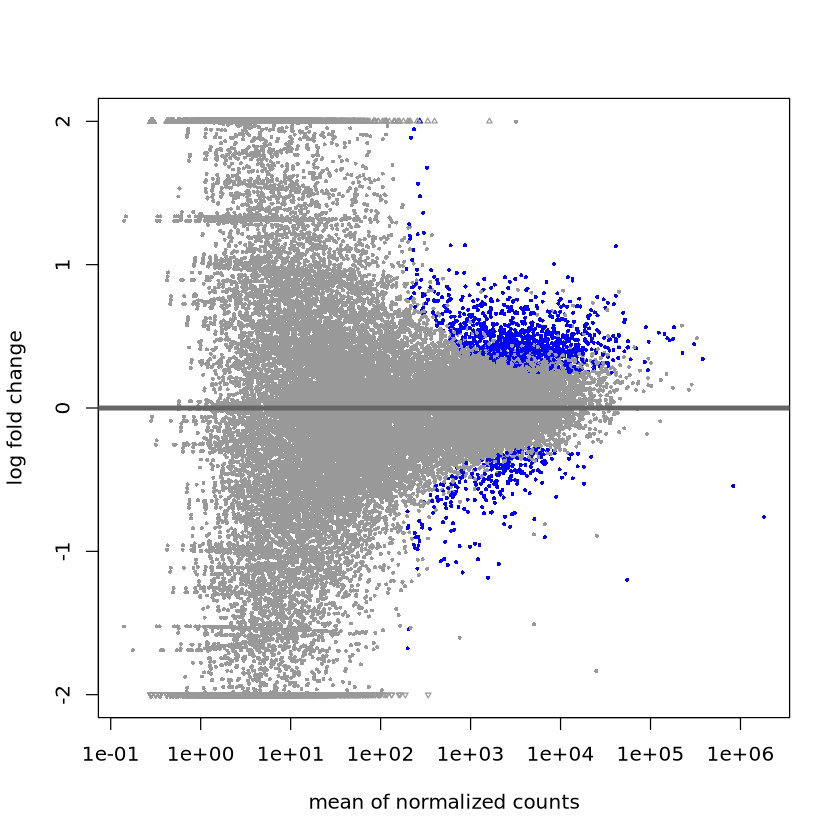

In [19]:
plotMA(res, ylim=c(-2,2))

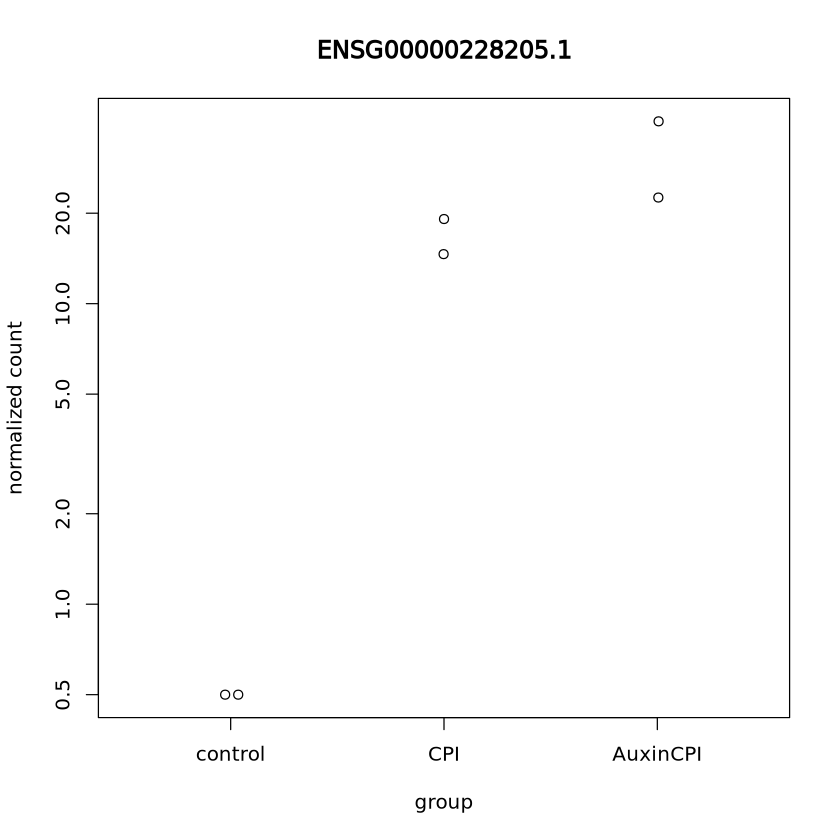

In [20]:
plotCounts(dds, gene=which.max(res$log2FoldChange), intgroup="condition")

In [21]:
#write.csv(as.data.frame(resOrdered), 
#          file="condition_treated_results.csv")

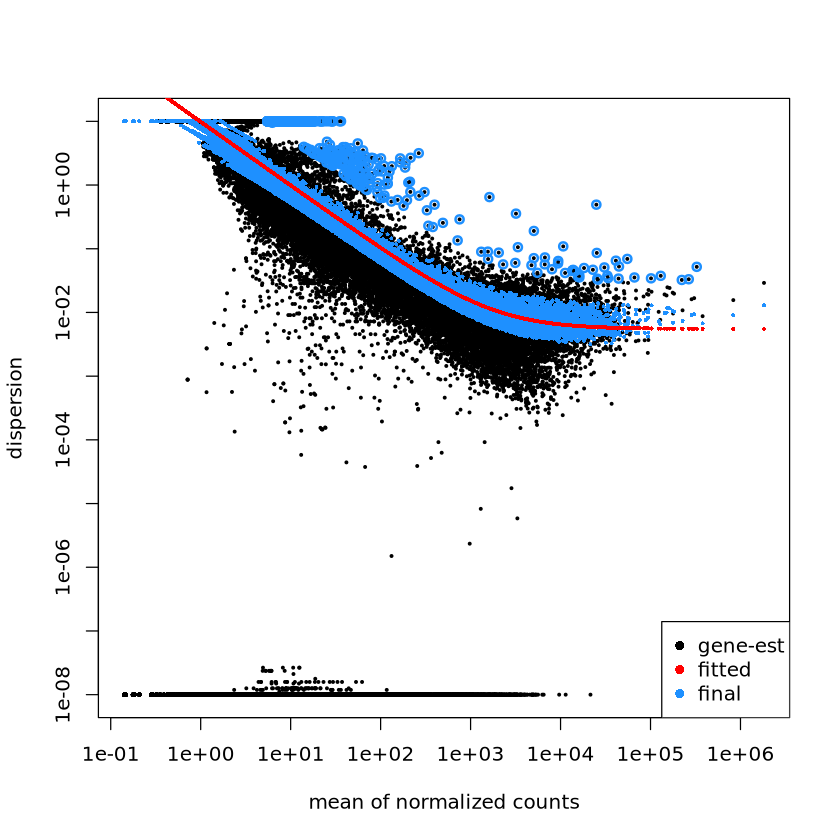

In [22]:
plotDispEsts(dds)

### Transform - VST main

In [23]:
vsd <- vst(dds, blind=FALSE)
head(assay(vsd), 3)

,/usr/users/papantonis1/aman/rnaseq_data/star_results/S55_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S56_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S57_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S58_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S59_Aligned.sortedByCoord.out.bam,/usr/users/papantonis1/aman/rnaseq_data/star_results/S60_Aligned.sortedByCoord.out.bam
ENSG00000290825.2,8.763552,8.763552,8.763552,8.763552,8.853386,8.763552
ENSG00000223972.6,8.763552,8.763552,8.763552,8.763552,8.763552,8.763552
ENSG00000310526.1,9.192389,9.358516,9.942039,9.888528,9.948701,10.029176


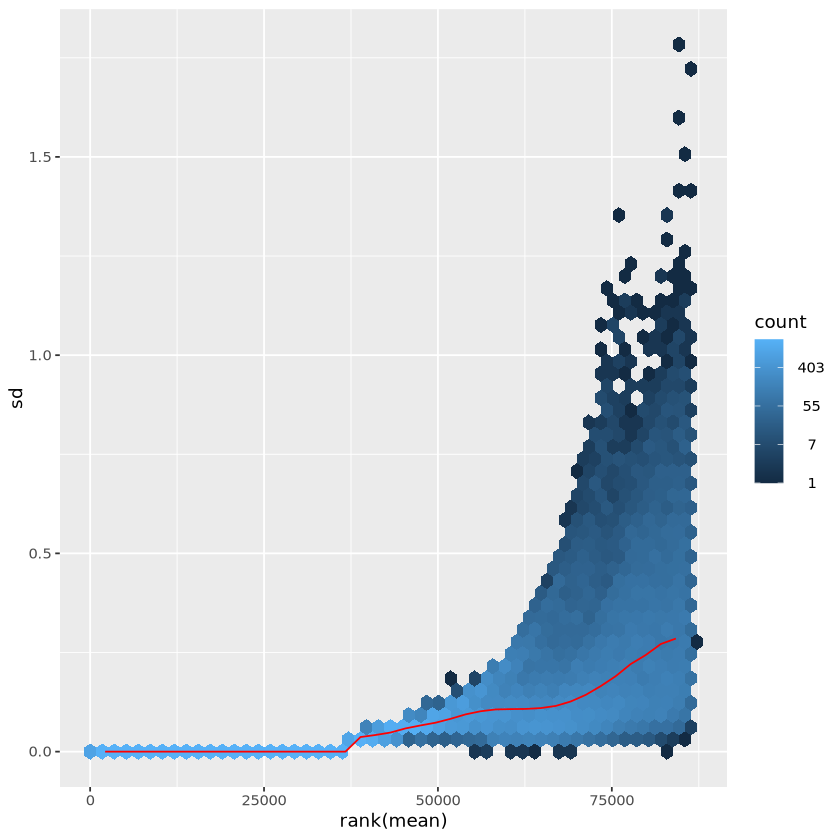

In [24]:
library("vsn")
meanSdPlot(assay(vsd))

### NormTransform

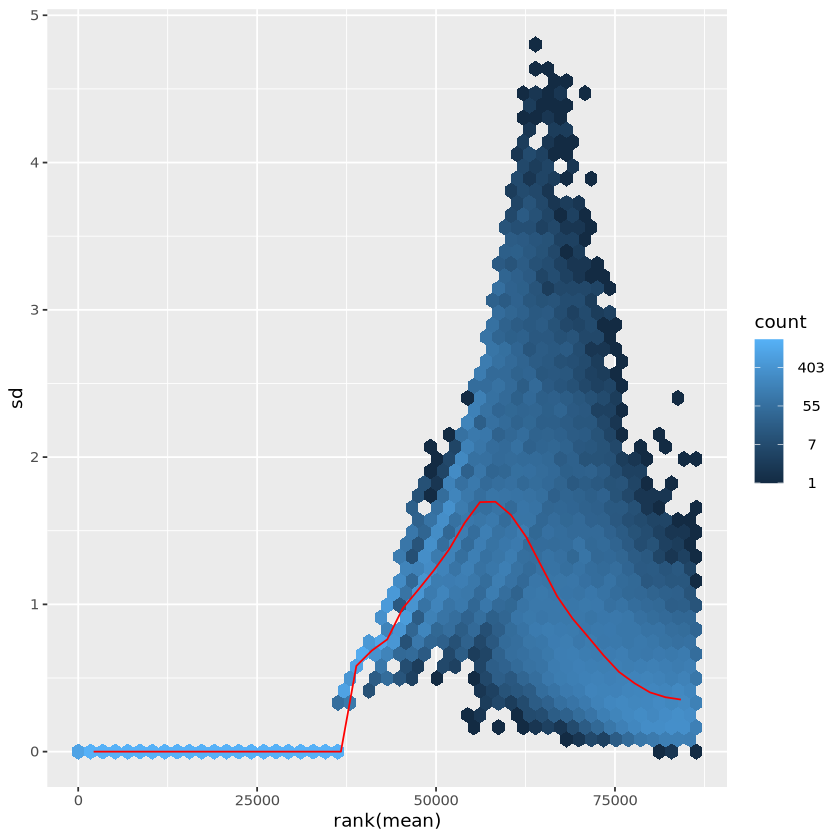

In [25]:
ntd <- normTransform(dds)
meanSdPlot(assay(ntd))

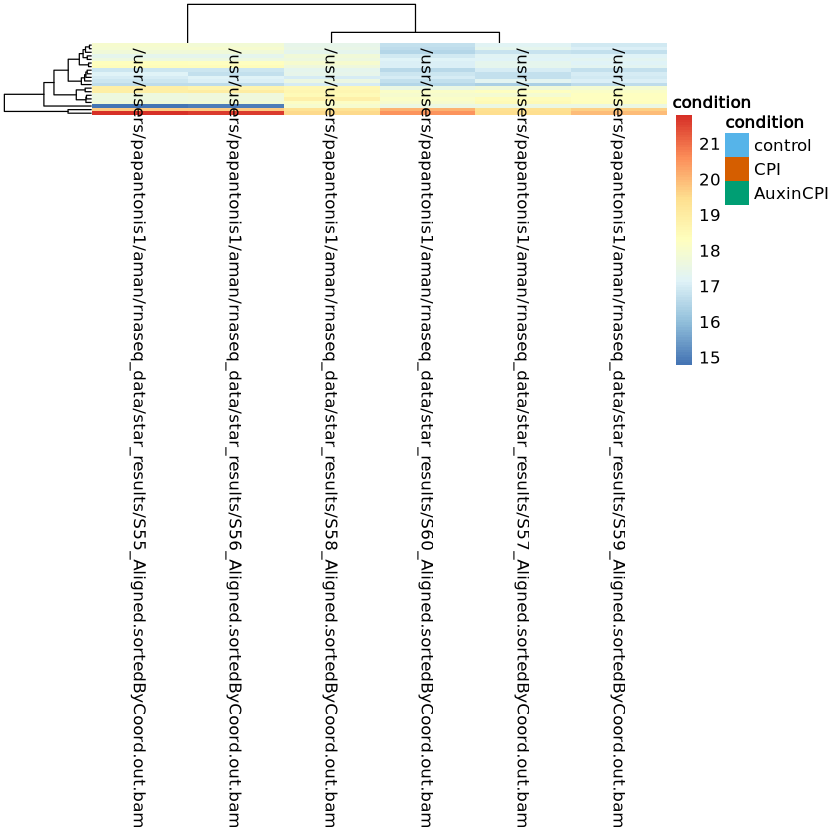

In [26]:
library("pheatmap")

select <- order(rowMeans(counts(dds, normalized=TRUE)), decreasing=TRUE)[1:20]


# Reassign colnames and ensure annotation matches order
colnames(vsd) <- c("S55", "S56", "S57", "S58", "S59", "S60")
df <- as.data.frame(colData(dds)[, "condition", drop = FALSE])
rownames(df) <- colnames(vsd)
df$condition <- factor(df$condition, levels = c("control", "CPI", "AuxinCPI"))



# Define annotation colors
ann_colors <- list(
  condition = c("control" = "#56B4E9", "CPI" = "#D55E00", "AuxinCPI" = "#009E73")
)

pheatmap(
  assay(ntd)[select, ],
  cluster_rows = TRUE,
  show_rownames = FALSE,
  cluster_cols = TRUE,
  annotation_col = df,
  annotation_colors = ann_colors
)


In [27]:
all(colnames(assay(vsd)) == rownames(df))

[1] TRUE

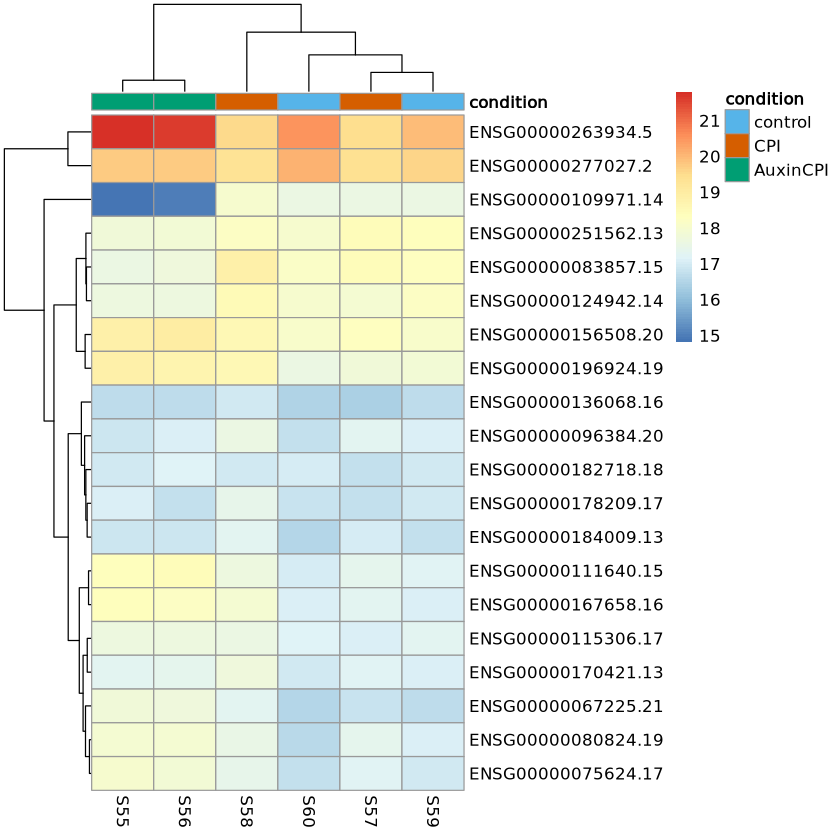

In [28]:
colnames(vsd) <- c("S55", "S56", "S57", "S58", "S59", "S60")
pheatmap(
  assay(vsd)[select, ],
  cluster_rows = TRUE,
  show_rownames = TRUE,
  cluster_cols = TRUE,
  annotation_col = df,
  annotation_colors = ann_colors
)

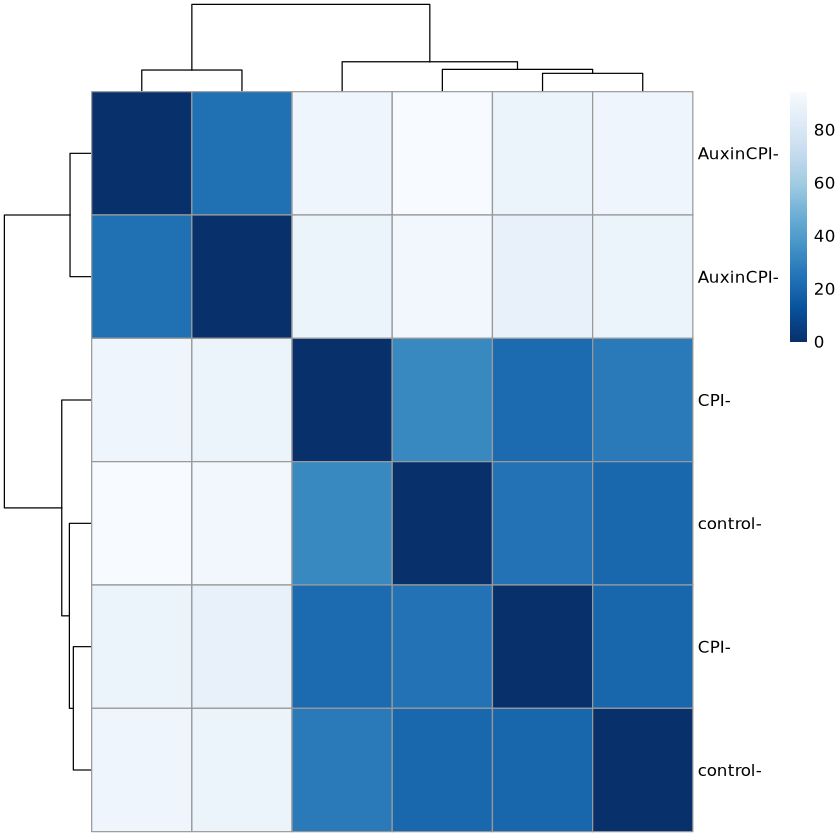

In [29]:
sampleDists <- dist(t(assay(vsd)))
library("RColorBrewer")
sampleDistMatrix <- as.matrix(sampleDists)
rownames(sampleDistMatrix) <- paste(vsd$condition, vsd$type, sep="-")
colnames(sampleDistMatrix) <- NULL
colors <- colorRampPalette( rev(brewer.pal(9, "Blues")) )(255)
pheatmap(sampleDistMatrix,
         clustering_distance_rows=sampleDists,
         clustering_distance_cols=sampleDists,
         col=colors)

# control and cpi correlated which in a way makes sense biologically

using ntop=500 top features by variance



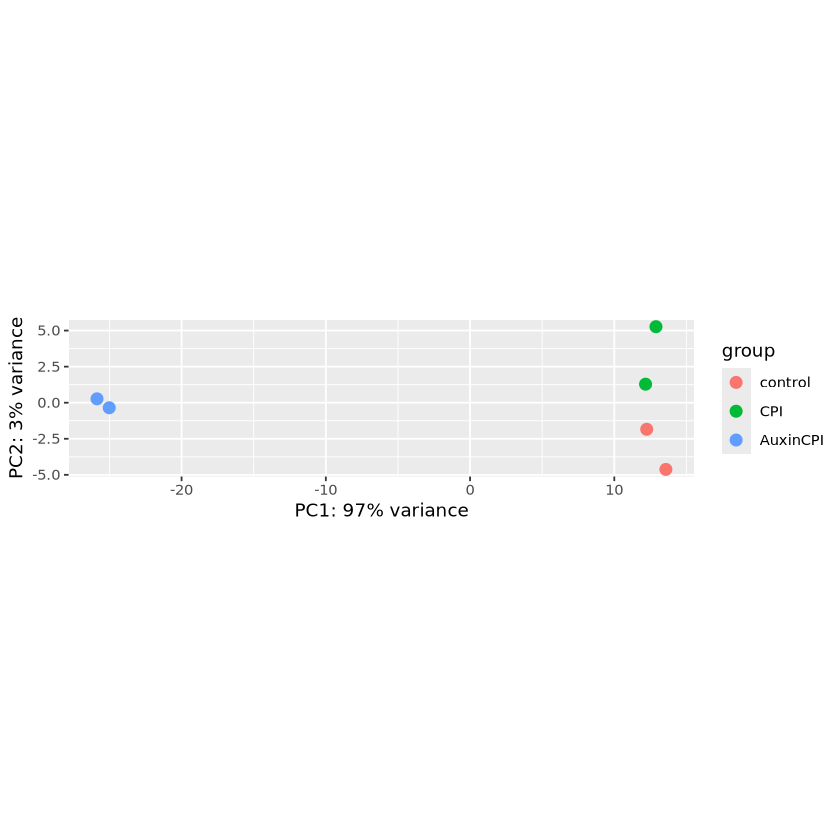

In [30]:
plotPCA(vsd, intgroup=c("condition"))

In [31]:
#options(repr.plot.width = 8, repr.plot.height = 9)
#plotPCA(vsd, intgroup = "condition") + theme(aspect.ratio = 1.5)
pca <- prcomp(t(assay(vsd)))
summary(pca)



Importance of components:
                           PC1      PC2     PC3     PC4     PC5      PC6
Standard deviation     45.4993 10.57308 7.46943 5.94246 5.55822 1.41e-13
Proportion of Variance  0.8985  0.04852 0.02422 0.01533 0.01341 0.00e+00
Cumulative Proportion   0.8985  0.94705 0.97126 0.98659 1.00000 1.00e+00

### Log fold change shrinkage

In [32]:
resultsNames(dds)

[1] "Intercept"                     "condition_CPI_vs_control"     
[3] "condition_AuxinCPI_vs_control"

In [33]:
resLFC <- lfcShrink(dds, coef="condition_CPI_vs_control", type="apeglm")
resLFC

using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



log2 fold change (MAP): condition CPI vs control 
Wald test p-value: condition CPI vs control 
DataFrame with 86364 rows and 5 columns
                    baseMean log2FoldChange     lfcSE    pvalue      padj
                   <numeric>      <numeric> <numeric> <numeric> <numeric>
ENSG00000290825.2   0.280936    -0.00182447  0.126213  0.621326        NA
ENSG00000223972.6   0.000000             NA        NA        NA        NA
ENSG00000310526.1 227.447545    -0.02542982  0.120621  0.556467  0.806729
ENSG00000227232.6   0.000000             NA        NA        NA        NA
ENSG00000278267.1   0.000000             NA        NA        NA        NA
...                      ...            ...       ...       ...       ...
ENSG00000303867.1          0             NA        NA        NA        NA
ENSG00000303902.1          0             NA        NA        NA        NA
ENSG00000306528.1          0             NA        NA        NA        NA
ENSG00000297844.1          0             NA        

In [34]:
# order based on the pval
resOrdered <- res[order(res$pvalue),]
resOrdered

log2 fold change (MLE): condition CPI vs control 
Wald test p-value: condition CPI vs control 
DataFrame with 86364 rows and 6 columns
                    baseMean log2FoldChange     lfcSE      stat      pvalue
                   <numeric>      <numeric> <numeric> <numeric>   <numeric>
ENSG00000170385.10   8457.71       1.003893  0.114580   8.76151 1.92644e-18
ENSG00000100600.15   4123.34       0.913378  0.140299   6.51021 7.50440e-11
ENSG00000104805.17   3677.86       0.926150  0.145961   6.34520 2.22138e-10
ENSG00000169116.11  10740.23       0.715329  0.113664   6.29336 3.10658e-10
ENSG00000067141.17   2414.47       0.912804  0.152194   5.99763 2.00223e-09
...                      ...            ...       ...       ...         ...
ENSG00000303867.1          0             NA        NA        NA          NA
ENSG00000303902.1          0             NA        NA        NA          NA
ENSG00000306528.1          0             NA        NA        NA          NA
ENSG00000297844.1          0 

In [35]:
# filtering with padj < 0.05
sum(res$padj < 0.05, na.rm=TRUE)

[1] 849

In [36]:
res_raw <- results(dds, contrast = c("condition", "CPI", "control"))

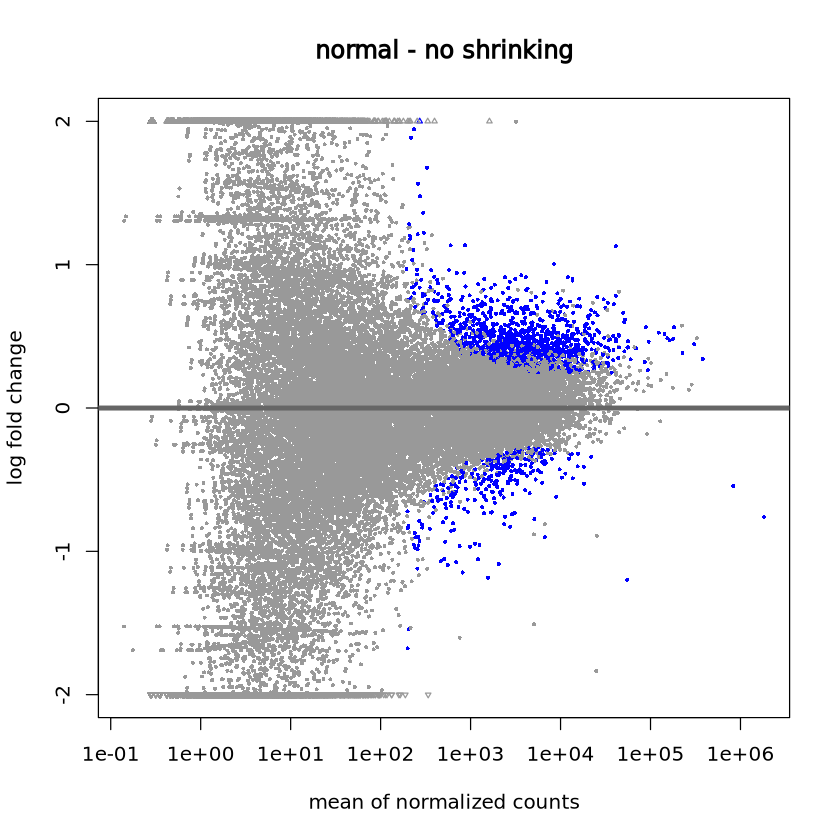

In [37]:
plotMA(res_raw, ylim=c(-2,2), main="normal - no shrinking")

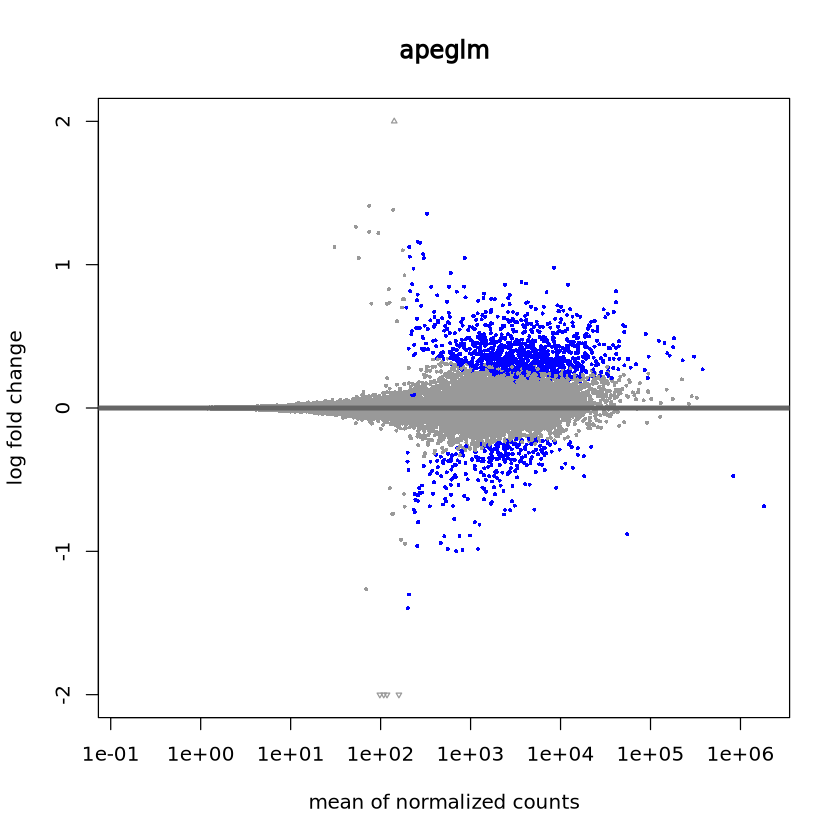

In [38]:
plotMA(resLFC, ylim=c(-2,2), main="apeglm")

In [39]:
mcols(res)$description

[1] "mean of normalized counts for all samples"       
[2] "log2 fold change (MLE): condition CPI vs control"
[3] "standard error: condition CPI vs control"        
[4] "Wald statistic: condition CPI vs control"        
[5] "Wald test p-value: condition CPI vs control"     
[6] "BH adjusted p-values"

In [40]:
sig_res <- res[which(res$padj < 0.1), ]

In [41]:
sig_res

log2 fold change (MLE): condition CPI vs control 
Wald test p-value: condition CPI vs control 
DataFrame with 1332 rows and 6 columns
                    baseMean log2FoldChange     lfcSE      stat      pvalue
                   <numeric>      <numeric> <numeric> <numeric>   <numeric>
ENSG00000187961.15   637.683      -0.803631 0.2106553  -3.81491 1.36232e-04
ENSG00000078808.20  5833.847       0.345820 0.1188151   2.91058 3.60763e-03
ENSG00000131584.19  2362.876      -0.809808 0.1619122  -5.00152 5.68792e-07
ENSG00000107404.21  3137.363      -0.504762 0.1277532  -3.95107 7.78017e-05
ENSG00000221978.13 15586.896      -0.318604 0.0864294  -3.68629 2.27550e-04
...                      ...            ...       ...       ...         ...
ENSG00000071553.18  5928.334       0.468645  0.126512   3.70435 0.000211935
ENSG00000160211.20  9452.744       0.433809  0.138695   3.12780 0.001761214
ENSG00000198888.2    449.944       0.594330  0.227863   2.60827 0.009100002
ENSG00000198804.2   7366.769  

In [42]:
upregulated <- sig_res[which(sig_res$log2FoldChange > 0.6), ]
up_genes <- rownames(upregulated)

In [43]:
downregulated <- sig_res[which(sig_res$log2FoldChange < - 0.6), ]
down_genes <- rownames(downregulated)

In [44]:
length(up_genes)

[1] 222

In [45]:
length(down_genes)

[1] 82

In [46]:
setwd("/usr/users/papantonis1/aman/rnaseq_data")

In [47]:
# res: DESeq2 results for contrast (already computed)
res_df <- as.data.frame(res)
res_df$gene_id <- rownames(res_df)                
res_df$gene_id <- sub("\\.\\d+$","", res_df$gene_id)  # strip .version

# reorder cols
res_df <- res_df[, c("gene_id","baseMean","log2FoldChange","lfcSE","stat","pvalue","padj")]

write.table(res_df,
            file = "deseq_results_full_cpionly_3sep.tsv",
            sep = "\t", quote = FALSE, row.names = FALSE)


In [48]:
res_df

,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000290825.2,ENSG00000290825,0.2809356,-2.4225869,4.9043005,-0.4939720,0.6213260,NA
ENSG00000223972.6,ENSG00000223972,0.0000000,NA,NA,NA,NA,NA
ENSG00000310526.1,ENSG00000310526,227.4475449,-0.1891648,0.3216559,-0.5880968,0.5564673,0.806729
ENSG00000227232.6,ENSG00000227232,0.0000000,NA,NA,NA,NA,NA
ENSG00000278267.1,ENSG00000278267,0.0000000,NA,NA,NA,NA,NA
ENSG00000243485.6,ENSG00000243485,0.8671304,-1.2558526,4.6978373,-0.2673257,0.7892184,NA
ENSG00000284332.1,ENSG00000284332,0.0000000,NA,NA,NA,NA,NA
ENSG00000237613.3,ENSG00000237613,0.0000000,NA,NA,NA,NA,NA
ENSG00000308361.1,ENSG00000308361,0.2079744,0.0000000,4.9974550,0.0000000,1.0000000,NA


In [50]:
padj_thr <- 0.1
lfc_thr  <- 0.6

sig <- subset(res_df, !is.na(padj) & padj < padj_thr & abs(log2FoldChange) >= lfc_thr)
up   <- subset(sig, log2FoldChange >=  lfc_thr)
down <- subset(sig, log2FoldChange <= -lfc_thr)

# IDs only (one per line)
write.table(up$gene_id,   file="upregulated_genes_deseq_3sep.txt",
            sep="\t", quote=FALSE, row.names=FALSE, col.names=FALSE)
write.table(down$gene_id, file="downregulated_genes_deseq_3sep.txt",
            sep="\t", quote=FALSE, row.names=FALSE, col.names=FALSE)

# If you also want a small table with IDs + log2FC
write.table(up[, c("gene_id","log2FoldChange")],
            file="upregulated_genes_withLFC_3sep.tsv",
            sep="\t", quote=FALSE, row.names=FALSE)
write.table(down[, c("gene_id","log2FoldChange")],
            file="downregulated_genes_withLFC_3sep.tsv",
            sep="\t", quote=FALSE, row.names=FALSE)

up

,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000171603.18,ENSG00000171603,10545.1022,0.6236341,0.1608003,3.878313,1.051832e-04,5.221563e-03
ENSG00000083444.17,ENSG00000083444,11068.2774,0.6531234,0.1401255,4.660990,3.146924e-06,6.674912e-04
ENSG00000117298.16,ENSG00000117298,6316.9610,0.7427075,0.1784315,4.162424,3.148870e-05,2.367634e-03
ENSG00000133216.17,ENSG00000133216,2722.2802,0.8813826,0.1955833,4.506430,6.592753e-06,9.860393e-04
ENSG00000090020.11,ENSG00000090020,3296.3819,0.7566302,0.1868614,4.049153,5.140340e-05,3.260502e-03
ENSG00000204138.13,ENSG00000204138,2796.9991,0.6088367,0.1750841,3.477395,5.063119e-04,1.435566e-02
ENSG00000134690.11,ENSG00000134690,2154.2006,0.6600042,0.1824975,3.616512,2.986000e-04,1.030612e-02
ENSG00000117399.14,ENSG00000117399,9237.0644,0.7998670,0.1770146,4.518649,6.223550e-06,9.680524e-04
ENSG00000142949.18,ENSG00000142949,25591.6602,0.7740623,0.2658500,2.911651,3.595241e-03,4.973741e-02


In [47]:
#write.table(up_genes, file="upregulated_genes.txt", quote=FALSE, row.names=FALSE, col.names=FALSE)
#write.table(down_genes, file="downregulated_genes.txt", quote=FALSE, row.names=FALSE, col.names=FALSE)

In [48]:
up_df <- data.frame(
  ensembl = rownames(upregulated),
  log2FC = upregulated$log2FoldChange
)

write.table(up_df, file = "upregulated_genes.txt", sep = "\t", quote = FALSE, row.names = FALSE)

In [49]:
down_df <- data.frame(
  ensembl = rownames(downregulated),
  log2FC = downregulated$log2FoldChange
)
write.table(down_df, file = "downregulated_genes.txt", sep = "\t", quote = FALSE, row.names = FALSE)

In [50]:
# Full result from DESeq2, no filtering by padj
gene_df <- data.frame(
  ensembl = rownames(res),
  log2FC = res$log2FoldChange
)

# Optional: remove NA
gene_df <- na.omit(gene_df)

# Write full ranked gene list for GSEA
write.table(gene_df, file = "ranked_gene_list.txt", sep = "\t", quote = FALSE, row.names = FALSE)

gene_df

,ensembl,log2FC
,<chr>,<dbl>
1,ENSG00000290825.2,-2.42258691
3,ENSG00000310526.1,-0.18916477
6,ENSG00000243485.6,-1.25585264
9,ENSG00000308361.1,0.00000000
14,ENSG00000241860.8,-0.16632248
18,ENSG00000308579.1,-1.95519125
20,ENSG00000269981.1,1.30369400
23,ENSG00000222623.1,-1.68987839
26,ENSG00000310527.1,-0.39200970


In [51]:
summary(gene_df)

   ensembl              log2FC         
 Length:49321       Min.   :-6.452813  
 Class :character   1st Qu.:-0.239804  
 Mode  :character   Median : 0.000000  
                    Mean   :-0.004435  
                    3rd Qu.: 0.247107  
                    Max.   : 6.559015  

In [52]:
up_df

ensembl,log2FC
<chr>,<dbl>
ENSG00000171603.18,0.6236341
ENSG00000083444.17,0.6531234
ENSG00000117298.16,0.7427075
ENSG00000133216.17,0.8813826
ENSG00000090020.11,0.7566302
ENSG00000204138.13,0.6088367
ENSG00000134690.11,0.6600042
ENSG00000117399.14,0.7998670
ENSG00000142949.18,0.7740623


In [53]:
down_df

ensembl,log2FC
<chr>,<dbl>
ENSG00000187961.15,-0.8036312
ENSG00000131584.19,-0.8098075
ENSG00000197530.13,-0.6306522
ENSG00000158286.13,-0.7327465
ENSG00000215788.11,-0.6237641
ENSG00000142733.18,-0.7232720
ENSG00000200087.1,-1.1987023
ENSG00000274210.1,-0.9842403
ENSG00000143630.10,-0.9750524


Loading required package: ggplot2

Loading required package: ggrepel



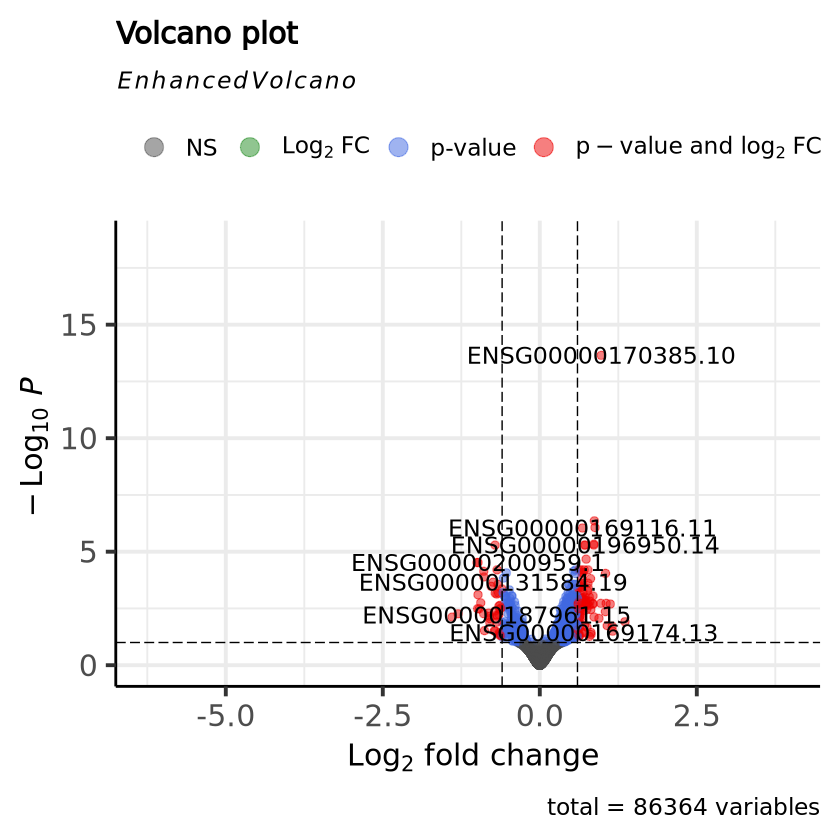

In [54]:
library(EnhancedVolcano)
EnhancedVolcano(resLFC,
  lab = rownames(resLFC),
  x = 'log2FoldChange',
  y = 'padj',
  pCutoff = 0.1,
  FCcutoff = 0.6)

# resLFC used as it is the shrunk one

### The next step is to display the gene names instead of the ensembl ids

In [55]:
# todo

In [56]:
# Skip 'version="devel"' which pulls the latest (3.22, needs R 4.5)
#BiocManager::install(version = "3.18")
#BiocManager::install("biomaRt")


In [57]:
library(biomaRt)

In [58]:
# Set up biomart
mart <- useEnsembl(biomart = "genes", dataset = "hsapiens_gene_ensembl")

# Remove version suffix (.10, .11 etc.)
ids <- gsub("\\..*", "", rownames(resLFC))

# Query gene names
annot <- getBM(
  attributes = c("ensembl_gene_id", "hgnc_symbol"),
  filters = "ensembl_gene_id",
  values = ids,
  mart = mart
)

In [59]:
annot

ensembl_gene_id,hgnc_symbol
<chr>,<chr>
ENSG00000000938,FGR
ENSG00000001460,STPG1
ENSG00000001461,NIPAL3
ENSG00000004455,AK2
ENSG00000004487,KDM1A
ENSG00000006555,TTC22
ENSG00000007341,ST7L
ENSG00000007923,DNAJC11
ENSG00000007968,E2F2


In [60]:
# Merge with result table
resLFC$ensembl_id <- gsub("\\..*", "", rownames(resLFC))
res_annot <- merge(as.data.frame(resLFC), annot, by.x = "ensembl_id", by.y = "ensembl_gene_id", all.x = TRUE)

# Set gene symbols as rownames (fallback to Ensembl if missing)
res_annot$label <- ifelse(res_annot$hgnc_symbol == "", res_annot$ensembl_id, res_annot$hgnc_symbol)

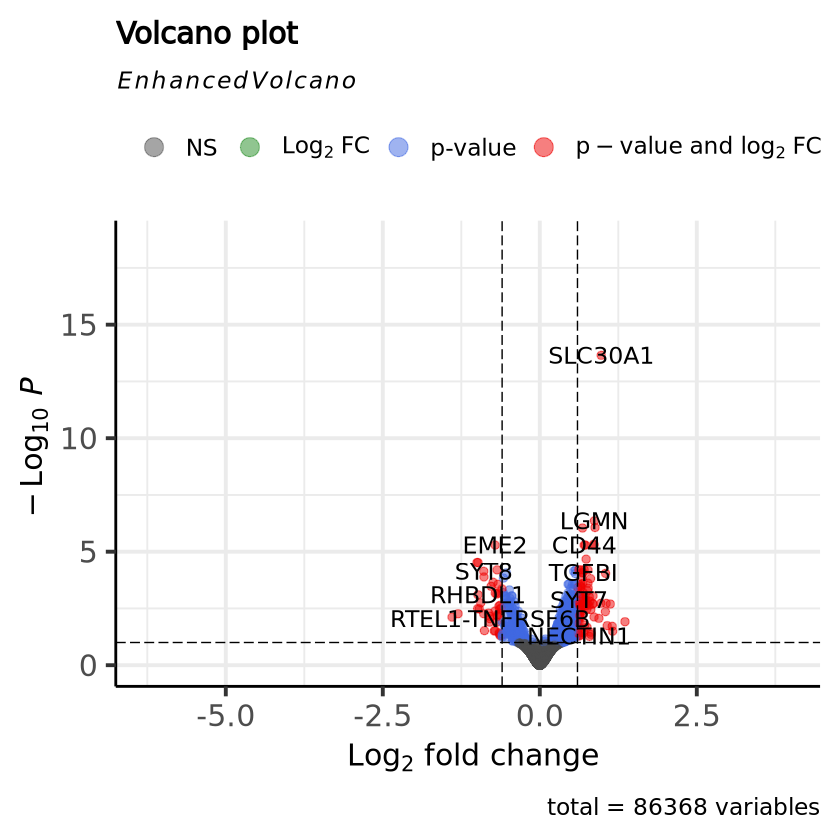

In [61]:
EnhancedVolcano(
  res_annot,
  lab = res_annot$label,
  x = 'log2FoldChange',
  y = 'padj',
  pCutoff = 0.1,
  FCcutoff = 0.6
)


In [62]:
head(up_df)

,ensembl,log2FC
,<chr>,<dbl>
1,ENSG00000171603.18,0.6236341
2,ENSG00000083444.17,0.6531234
3,ENSG00000117298.16,0.7427075
4,ENSG00000133216.17,0.8813826
5,ENSG00000090020.11,0.7566302
6,ENSG00000204138.13,0.6088367


In [63]:
head(down_df)

,ensembl,log2FC
,<chr>,<dbl>
1,ENSG00000187961.15,-0.8036312
2,ENSG00000131584.19,-0.8098075
3,ENSG00000197530.13,-0.6306522
4,ENSG00000158286.13,-0.7327465
5,ENSG00000215788.11,-0.6237641
6,ENSG00000142733.18,-0.7232720


In [64]:
# Load biomaRt
library(biomaRt)

# Strip version suffixes
up_df$ensembl_id <- sub("\\..*", "", up_df$ensembl)
down_df$ensembl_id <- sub("\\..*", "", down_df$ensembl)

# Connect to Ensembl
mart <- useEnsembl(biomart = "genes", dataset = "hsapiens_gene_ensembl")

# Get gene symbols
gene_info <- getBM(
  attributes = c("ensembl_gene_id", "hgnc_symbol"),
  filters = "ensembl_gene_id",
  values = unique(c(up_df$ensembl_id, down_df$ensembl_id)),
  mart = mart
)

# Merge gene symbols with up_df
up_df_annot <- merge(up_df, gene_info, by.x = "ensembl_id", by.y = "ensembl_gene_id", all.x = TRUE)

# Merge gene symbols with down_df
down_df_annot <- merge(down_df, gene_info, by.x = "ensembl_id", by.y = "ensembl_gene_id", all.x = TRUE)

In [65]:
# Replace missing hgnc_symbol with ensembl_id
up_df_annot$hgnc_symbol <- ifelse(
  up_df_annot$hgnc_symbol == "" | is.na(up_df_annot$hgnc_symbol),
  up_df_annot$ensembl_id,
  up_df_annot$hgnc_symbol
)

down_df_annot$hgnc_symbol <- ifelse(
  down_df_annot$hgnc_symbol == "" | is.na(down_df_annot$hgnc_symbol),
  down_df_annot$ensembl_id,
  down_df_annot$hgnc_symbol
)


In [66]:
up_df_annot

ensembl_id,ensembl,log2FC,hgnc_symbol
<chr>,<chr>,<dbl>,<chr>
ENSG00000005339,ENSG00000005339.15,0.6531038,CREBBP
ENSG00000010292,ENSG00000010292.13,0.7112138,NCAPD2
ENSG00000011347,ENSG00000011347.10,0.6965520,SYT7
ENSG00000013288,ENSG00000013288.9,0.7036436,MAN2B2
ENSG00000026508,ENSG00000026508.21,0.7497931,CD44
ENSG00000030582,ENSG00000030582.19,0.9126872,GRN
ENSG00000041982,ENSG00000041982.17,0.6878423,TNC
ENSG00000044574,ENSG00000044574.9,1.1297088,HSPA5
ENSG00000047662,ENSG00000047662.5,1.3618516,FAM184B


In [67]:
down_df_annot

ensembl_id,ensembl,log2FC,hgnc_symbol
<chr>,<chr>,<dbl>,<chr>
ENSG00000026036,ENSG00000026036.23,-0.9577087,RTEL1-TNFRSF6B
ENSG00000101246,ENSG00000101246.20,-0.6434456,ARFRP1
ENSG00000103269,ENSG00000103269.14,-1.0960115,RHBDL1
ENSG00000105173,ENSG00000105173.14,-0.8496167,CCNE1
ENSG00000108465,ENSG00000108465.15,-0.6394644,CDK5RAP3
ENSG00000108960,ENSG00000108960.9,-0.6200365,MMD
ENSG00000111554,ENSG00000111554.15,-0.6692859,MDM1
ENSG00000118513,ENSG00000118513.21,-0.8976397,MYB
ENSG00000122870,ENSG00000122870.12,-0.9024617,BICC1


In [68]:
write.table(up_df_annot, file = "upregulated_genes_deseq.txt", sep = "\t", quote = FALSE, row.names = FALSE)
write.table(down_df_annot, file = "downregulated_genes_deseq.txt", sep = "\t", quote = FALSE, row.names = FALSE)

In [69]:
library(biomaRt)
library(clusterProfiler)
library(org.Hs.eg.db)
library(readr)
run_go_enrichment_from_file <- function(filepath, delim = "\t", symbol_col = "hgnc_symbol") {
  # Load gene list
  genes_df <- read_delim(filepath, delim = delim, show_col_types = FALSE)
  
  # Extract and standardize gene symbols
  symbols <- toupper(genes_df[[symbol_col]])
  
  # Map to Entrez IDs using BioMart
  mart <- useEnsembl(biomart = "genes", dataset = "hsapiens_gene_ensembl")
  converted <- getBM(
    filters = "hgnc_symbol",
    attributes = c("hgnc_symbol", "entrezgene_id"),
    values = symbols,
    mart = mart
  )
  converted <- na.omit(converted)

  # Perform GO enrichment if mappings exist
  if (nrow(converted) == 0) {
    message("No valid gene symbols could be mapped to Entrez IDs.")
    return(NULL)
  }

  ego <- enrichGO(
    gene          = converted$entrezgene_id,
    OrgDb         = org.Hs.eg.db,
    ont           = "BP",
    pAdjustMethod = "BH",
    pvalueCutoff  = 0.1,
    readable      = TRUE
  )

  return(ego)
}



clusterProfiler v4.10.0  For help: https://yulab-smu.top/biomedical-knowledge-mining-book/

If you use clusterProfiler in published research, please cite:
T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan, X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal enrichment tool for interpreting omics data. The Innovation. 2021, 2(3):100141


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:biomaRt’:

    select


The following object is masked from ‘package:IRanges’:

    slice


The following object is masked from ‘package:S4Vectors’:

    rename


The following object is masked from ‘package:stats’:

    filter


Loading required package: AnnotationDbi


Attaching package: ‘AnnotationDbi’


The following object is masked from ‘package:clusterProfiler’:

    select




Warning message:
“package ‘readr’ was built under R version 4.4.3”


In [70]:
ego_result_up_deseq <- run_go_enrichment_from_file("/usr/users/papantonis1/aman/rnaseq_data/upregulated_genes_deseq.txt")

# View results
as.data.frame(ego_result_up_deseq)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0031103,GO:0031103,axon regeneration,7/206,52/18870,1.472272e-06,0.003838192,0.002938429,DAG1/GRN/IGF1R/KREMEN1/NEO1/PTPRF/TNC,7
GO:0019058,GO:0019058,viral life cycle,15/206,321/18870,2.596586e-06,0.003838192,0.002938429,APOBEC3B/APOBEC3F/CR2/DAG1/EGFR/INSR/LAMP3/LDLR/NECTIN1/NECTIN2/NOTCH1/PCBP1/SELPLG/SLC1A5/SLC7A1,15
GO:0031102,GO:0031102,neuron projection regeneration,7/206,58/18870,3.130663e-06,0.003838192,0.002938429,DAG1/GRN/IGF1R/KREMEN1/NEO1/PTPRF/TNC,7
GO:0031099,GO:0031099,regeneration,11/206,191/18870,8.361473e-06,0.005082503,0.003891044,ATIC/CCN3/DAG1/GRN/IGF1R/KREMEN1/NEO1/NOTCH1/NR4A3/PTPRF/TNC,11
GO:0046718,GO:0046718,viral entry into host cell,10/206,156/18870,8.490750e-06,0.005082503,0.003891044,CR2/DAG1/EGFR/INSR/LDLR/NECTIN1/NECTIN2/SELPLG/SLC1A5/SLC7A1,10
GO:0044409,GO:0044409,entry into host,10/206,163/18870,1.248815e-05,0.005082503,0.003891044,CR2/DAG1/EGFR/INSR/LDLR/NECTIN1/NECTIN2/SELPLG/SLC1A5/SLC7A1,10
GO:0048679,GO:0048679,regulation of axon regeneration,5/206,30/18870,1.685471e-05,0.005082503,0.003891044,GRN/IGF1R/KREMEN1/NEO1/PTPRF,5
GO:0042267,GO:0042267,natural killer cell mediated cytotoxicity,7/206,76/18870,1.928430e-05,0.005082503,0.003891044,HLA-B/HLA-F/NECTIN2/TGFB1/TUBB/TUBB4B/ULBP1,7
GO:1903034,GO:1903034,regulation of response to wounding,10/206,173/18870,2.095712e-05,0.005082503,0.003891044,CADM4/EPHB2/F2R/GRN/IGF1R/KREMEN1/NEO1/PRKCD/PTPRF/SERPINE2,10


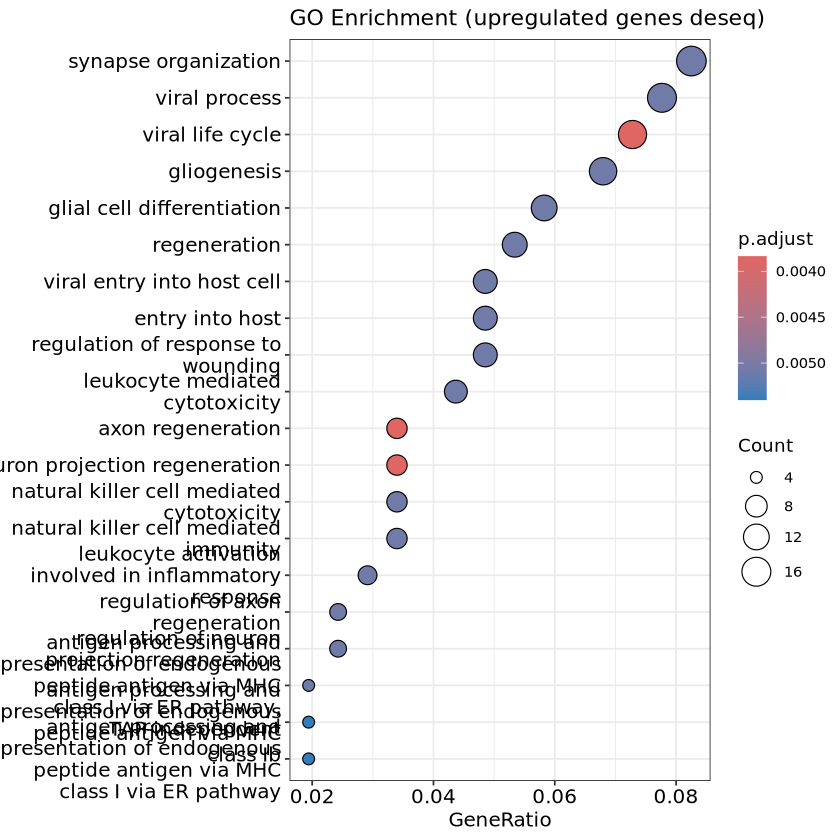

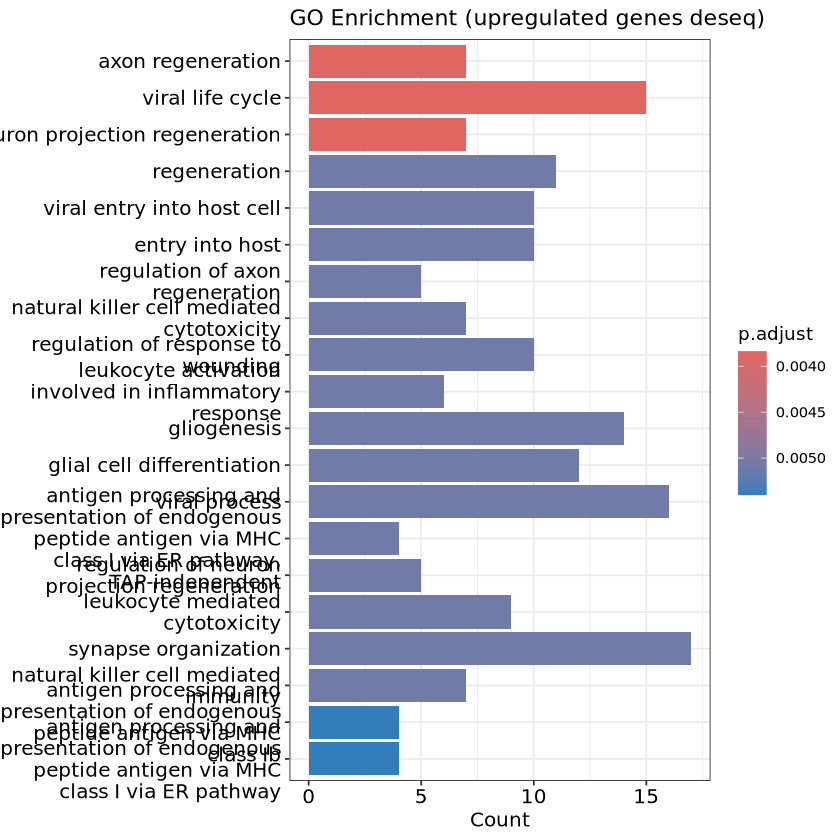

In [82]:
dotplot(ego_result_up_deseq, showCategory = 20, title = "GO Enrichment (upregulated genes deseq)")
barplot(ego_result_up_deseq, showCategory = 20, title = "GO Enrichment (upregulated genes deseq)")

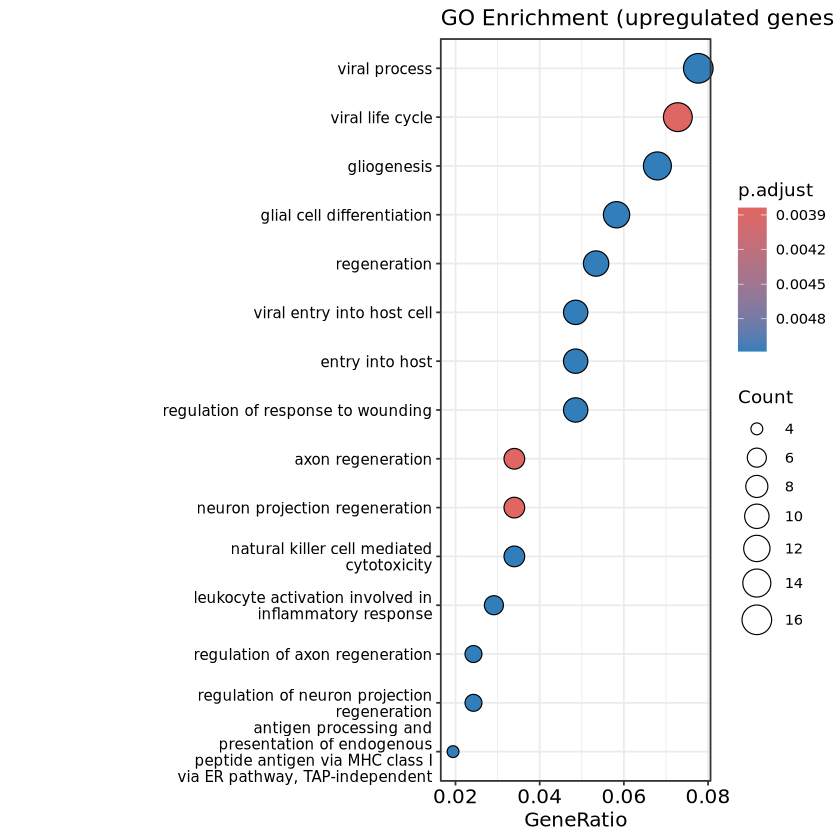

In [87]:
library(enrichplot)
library(ggplot2)
library(stringr)

p <- dotplot(
  ego_result_up_deseq,
  showCategory = 15,
  title = "GO Enrichment (upregulated genes deseq)",
  label_format = 35
) +
  theme(
    axis.text.y = element_text(size = 9),
    plot.margin = margin(5.5, 5.5, 5.5, 120, "pt")  # enlarge left margin
  ) +
  coord_cartesian(clip = "off")

p


In [72]:
library(biomaRt)
library(clusterProfiler)
library(org.Hs.eg.db)
library(readr)
run_go_enrichment_from_file <- function(filepath, delim = "\t", symbol_col = "hgnc_symbol") {
  # Load gene list
  genes_df <- read_delim(filepath, delim = delim, show_col_types = FALSE)
  
  # Extract and standardize gene symbols
  symbols <- toupper(genes_df[[symbol_col]])
  
  # Map to Entrez IDs using BioMart
  mart <- useEnsembl(biomart = "genes", dataset = "hsapiens_gene_ensembl")
  converted <- getBM(
    filters = "hgnc_symbol",
    attributes = c("hgnc_symbol", "entrezgene_id"),
    values = symbols,
    mart = mart
  )
  converted <- na.omit(converted)

  # Perform GO enrichment if mappings exist
  if (nrow(converted) == 0) {
    message("No valid gene symbols could be mapped to Entrez IDs.")
    return(NULL)
  }

  ego <- enrichGO(
    gene          = converted$entrezgene_id,
    OrgDb         = org.Hs.eg.db,
    ont           = "BP",
    pAdjustMethod = "BH",
    pvalueCutoff  = 0.2,
    readable      = TRUE
  )

  return(ego)
}

In [73]:
ego_result_down_deseq <- run_go_enrichment_from_file("/usr/users/papantonis1/aman/rnaseq_data/downregulated_genes_deseq.txt")

# View results
as.data.frame(ego_result_down_deseq)

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:1902460,GO:1902460,regulation of mesenchymal stem cell proliferation,2/53,10/18870,0.0003433275,0.1230311,0.1164953,CCNE1/LTBP3,2
GO:0097168,GO:0097168,mesenchymal stem cell proliferation,2/53,11/18870,0.0004188675,0.1230311,0.1164953,CCNE1/LTBP3,2
GO:0007127,GO:0007127,meiosis I,4/53,129/18870,0.0004710120,0.1230311,0.1164953,CCNE1/CCNE2/EME2/ING2,4
GO:0061982,GO:0061982,meiosis I cell cycle process,4/53,136/18870,0.0005749118,0.1230311,0.1164953,CCNE1/CCNE2/EME2/ING2,4


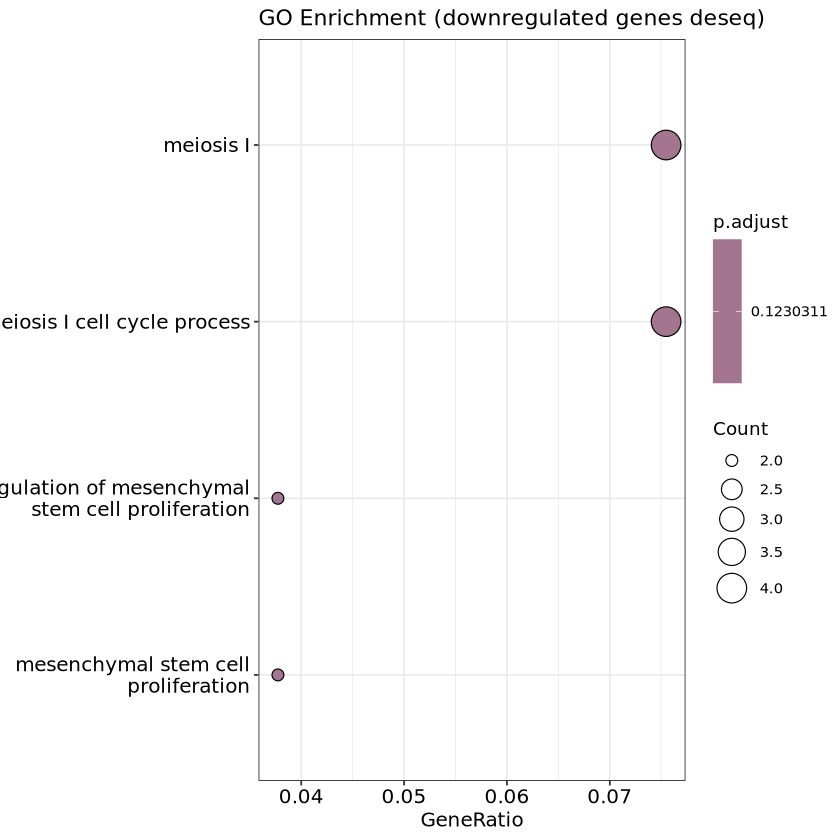

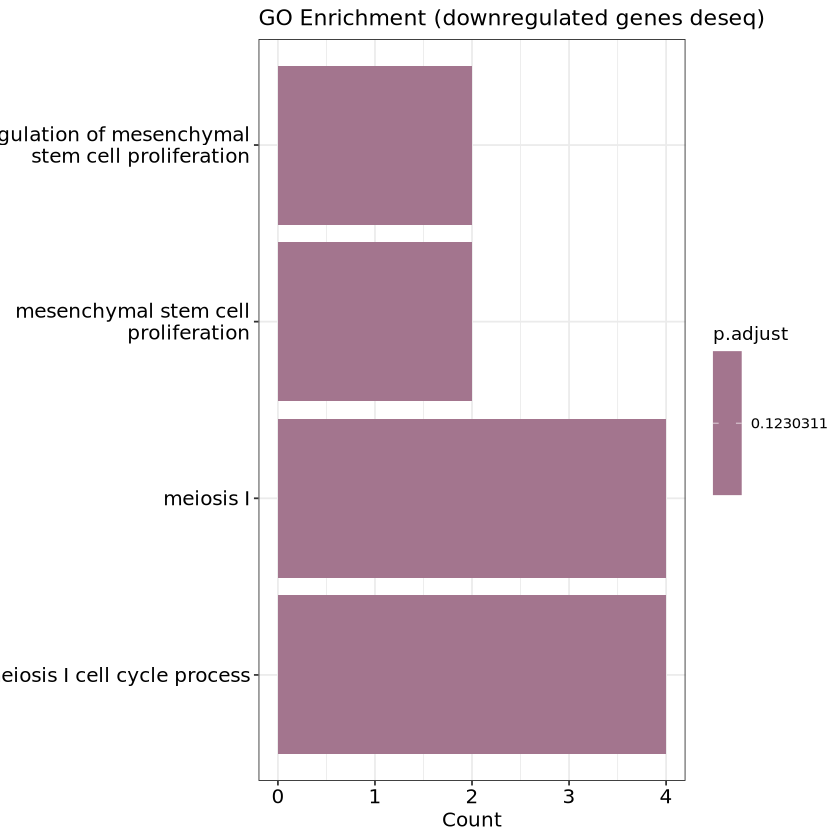

In [74]:
dotplot(ego_result_down_deseq, showCategory = 20, title = "GO Enrichment (downregulated genes deseq)")
barplot(ego_result_down_deseq, showCategory = 20, title = "GO Enrichment (downregulated genes deseq)")

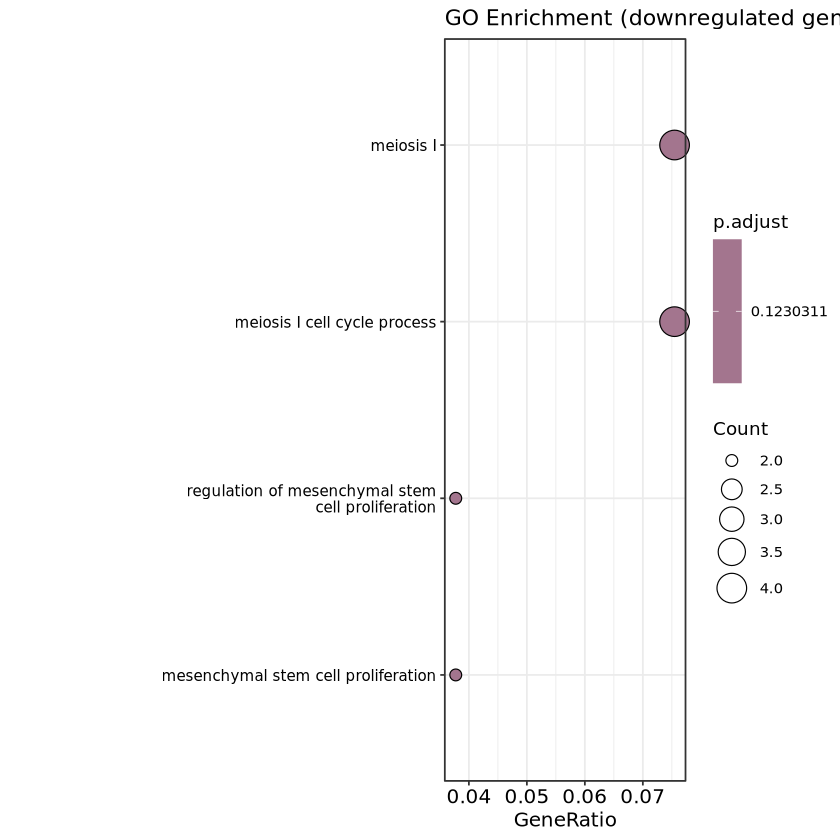

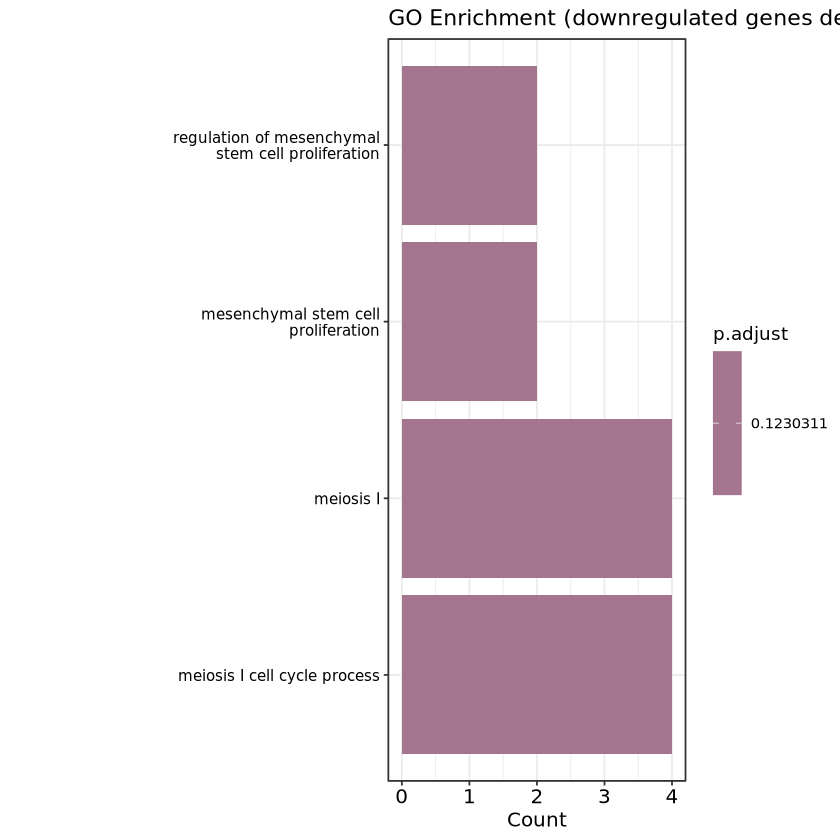

In [88]:
# dotplot for downregulated genes
p_down_dot <- dotplot(
  ego_result_down_deseq,
  showCategory = 20,
  title = "GO Enrichment (downregulated genes deseq)",
  label_format = 35
) +
  theme(
    axis.text.y = element_text(size = 9),
    plot.margin = margin(5.5, 5.5, 5.5, 120, "pt")  # extra space for long labels
  ) +
  coord_cartesian(clip = "off")

# barplot for downregulated genes
p_down_bar <- barplot(
  ego_result_down_deseq,
  showCategory = 20,
  title = "GO Enrichment (downregulated genes deseq)"
) +
  theme(
    axis.text.y = element_text(size = 9),
    plot.margin = margin(5.5, 5.5, 5.5, 120, "pt")
  ) +
  coord_cartesian(clip = "off")

p_down_dot
p_down_bar

In [75]:
# testing enrichr

In [76]:
c2 <- read.gmt("/usr/users/papantonis1/aman/rnaseq_data/c2.all.v2025.1.Hs.symbols.gmt")
enrich_res <- enricher(up_df_annot$hgnc_symbol, TERM2GENE = c2)

In [77]:
enrich_res

#
# over-representation test
#
#...@organism 	 UNKNOWN 
#...@ontology 	 UNKNOWN 
#...@gene 	 chr [1:222] "CREBBP" "NCAPD2" "SYT7" "MAN2B2" "CD44" "GRN" "TNC" "HSPA5" ...
#...pvalues adjusted by 'BH' with cutoff <0.05 
#...546 enriched terms found
'data.frame':	546 obs. of  9 variables:
 $ ID         : chr  "MILI_PSEUDOPODIA_CHEMOTAXIS_DN" "JOHNSTONE_PARVB_TARGETS_3_UP" "DEBIASI_APOPTOSIS_BY_REOVIRUS_INFECTION_DN" "FISCHER_G2_M_CELL_CYCLE" ...
 $ Description: chr  "MILI_PSEUDOPODIA_CHEMOTAXIS_DN" "JOHNSTONE_PARVB_TARGETS_3_UP" "DEBIASI_APOPTOSIS_BY_REOVIRUS_INFECTION_DN" "FISCHER_G2_M_CELL_CYCLE" ...
 $ GeneRatio  : chr  "28/215" "25/215" "20/215" "17/215" ...
 $ BgRatio    : chr  "429/22381" "433/22381" "276/22381" "236/22381" ...
 $ pvalue     : num  1.36e-15 7.79e-13 2.85e-12 1.43e-10 5.06e-10 ...
 $ p.adjust   : num  4.77e-12 1.37e-09 3.34e-09 1.26e-07 3.56e-07 ...
 $ qvalue     : num  3.43e-12 9.85e-10 2.40e-09 9.06e-08 2.56e-07 ...
 $ geneID     : chr  "GRN/HSPA5/PLOD1/APLP2/CNOT3

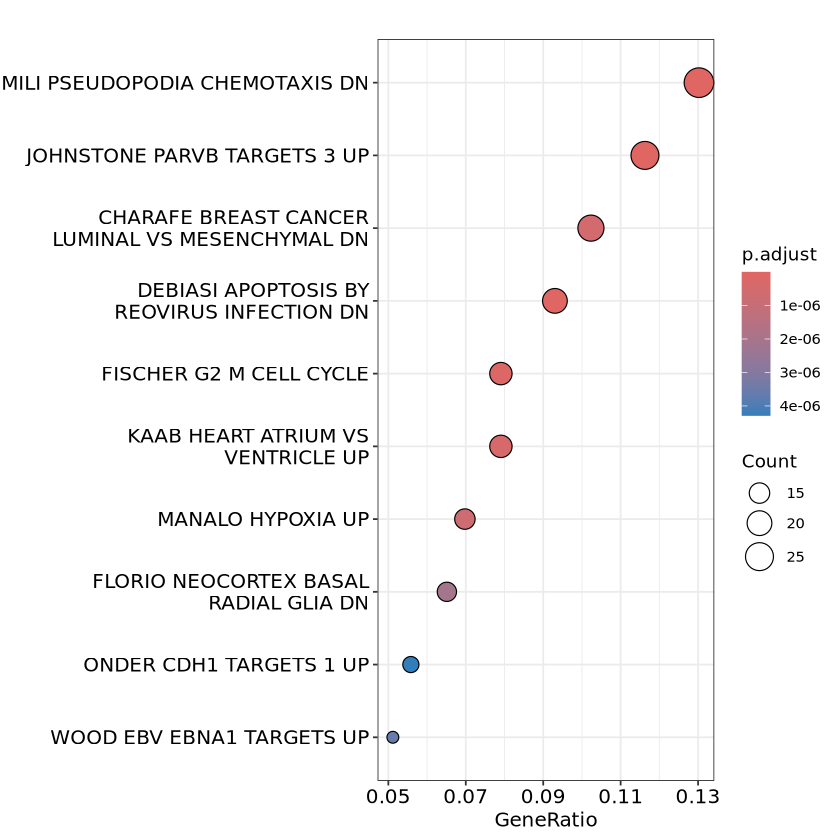

In [78]:
dotplot(enrich_res)

In [79]:
# All significant polycomb rel. set
subset(enrich_res@result, grepl("PRC2|POLYCOMB|H3K27|EZH2", Description, ignore.case = TRUE))

,ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>
LU_EZH2_TARGETS_DN,LU_EZH2_TARGETS_DN,LU_EZH2_TARGETS_DN,11/215,399/22381,0.001733167,0.01856814,0.01336586,LAMC2/ATP2B4/SRPX/CCN2/ETS1/IL17RD/EGFR/ALPP/MAGED1/BACE2/PHACTR4,11
ACEVEDO_LIVER_CANCER_WITH_H3K27ME3_DN,ACEVEDO_LIVER_CANCER_WITH_H3K27ME3_DN,ACEVEDO_LIVER_CANCER_WITH_H3K27ME3_DN,5/215,222/22381,0.063539302,0.18731301,0.13483305,CD44/PHGDH/NOMO3/NOMO1/EIF3C,5
MEISSNER_BRAIN_HCP_WITH_H3K4ME2_AND_H3K27ME3,MEISSNER_BRAIN_HCP_WITH_H3K4ME2_AND_H3K27ME3,MEISSNER_BRAIN_HCP_WITH_H3K4ME2_AND_H3K27ME3,2/215,60/22381,0.113330342,0.25365785,0.18258988,KCNQ1/NR4A3,2
MIKKELSEN_MCV6_HCP_WITH_H3K27ME3,MIKKELSEN_MCV6_HCP_WITH_H3K27ME3,MIKKELSEN_MCV6_HCP_WITH_H3K27ME3,7/215,438/22381,0.130361147,0.26845202,0.19323913,KCNQ1/NPTX2/TGFBI/CCN3/SEMA7A/COL13A1/NPTXR,7
LU_EZH2_TARGETS_UP,LU_EZH2_TARGETS_UP,LU_EZH2_TARGETS_UP,5/215,289/22381,0.146487999,0.27945648,0.20116044,GANAB/PHGDH/PCK2/APOBEC3F/PMVK,5
MEISSNER_NPC_HCP_WITH_H3K27ME3,MEISSNER_NPC_HCP_WITH_H3K27ME3,MEISSNER_NPC_HCP_WITH_H3K27ME3,2/215,79/22381,0.175940450,0.29553286,0.21273267,KCNQ1/CYP2S1,2
KONDO_EZH2_TARGETS,KONDO_EZH2_TARGETS,KONDO_EZH2_TARGETS,4/215,229/22381,0.179032376,0.30029583,0.21616119,CCN2/APP/EGFR/IL6R,4
KONDO_PROSTATE_CANCER_HCP_WITH_H3K27ME3,KONDO_PROSTATE_CANCER_HCP_WITH_H3K27ME3,KONDO_PROSTATE_CANCER_HCP_WITH_H3K27ME3,2/215,97/22381,0.238991092,0.34617259,0.24918453,CR2/FAM171A1,2
MIKKELSEN_NPC_HCP_WITH_H3K27ME3,MIKKELSEN_NPC_HCP_WITH_H3K27ME3,MIKKELSEN_NPC_HCP_WITH_H3K27ME3,5/215,346/22381,0.240167969,0.34744761,0.25010233,KCNQ1/LSR/CYP2S1/COL13A1/NPTXR,5


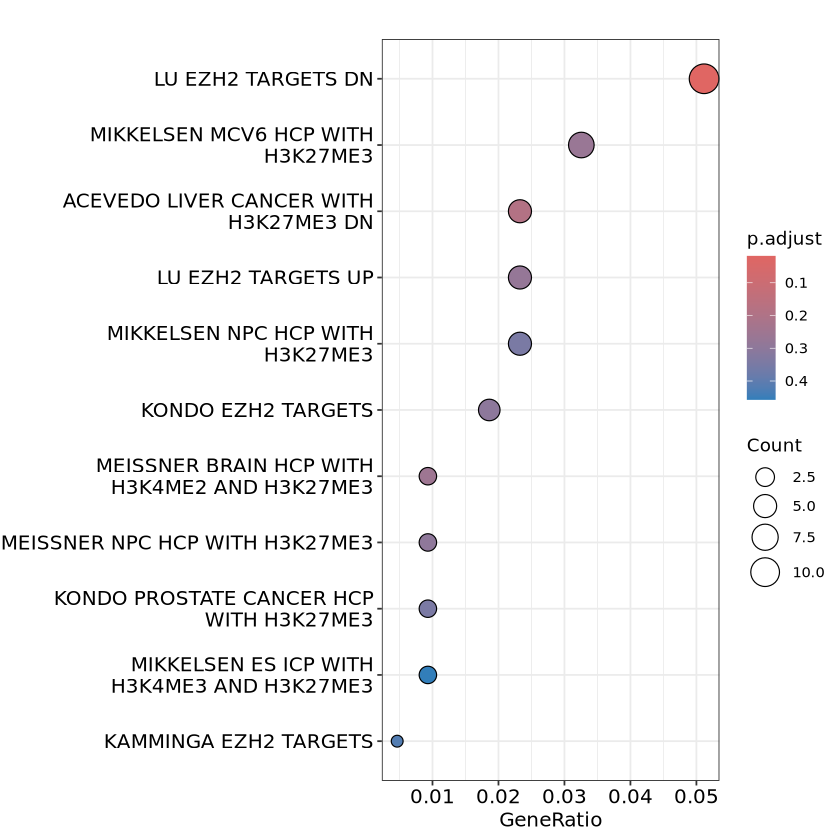

In [80]:
library(clusterProfiler)

# Subset the result data.frame
prc2_df <- subset(enrich_res@result, grepl("PRC2|POLYCOMB|H3K27|EZH2", Description, ignore.case=TRUE))

# If prc2_df is not empty, create a new enrichResult
if (nrow(prc2_df) > 0) {
  # Copy enrich_res and replace @result with prc2_df
  prc2_res <- enrich_res
  prc2_res@result <- prc2_df
  prc2_res@pvalueCutoff <- 0.5
  prc2_res@qvalueCutoff <- 0.5
  dotplot(prc2_res, showCategory=50)
}

In [81]:
# like this i could do with gsea too maybe?